# DATA 620 Project 2

In [45]:
import gzip
from collections import defaultdict

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from networkx.algorithms import bipartite

In [46]:
file_path = "wikiElec.ElecBs3.txt.gz"

## Introduction

For our project, we used the Wikipedia Requests for Adminship dataset from https://snap.stanford.edu/data/wiki-Elec.html to construct and analyze a network of voting interactions within the Wikipedia community.

- We first preprocessed the data by parsing election records and extracting voter–nominee relationships, focusing specifically on positive support votes to represent stronger ties.
- The original data forms a bipartite (two-mode) network consisting of voters and nominees, where edges represent votes cast during adminship elections.
- To better analyze relationships among nominees, we projected the bipartite network into a nominee-only network, where two nominees are connected if they share common voters.
    - Edge weights represent the number of shared supporters.
- To reduce the size and complexity of the network, we applied the island method, keeping only edges above a selected weight threshold to highlight stronger relationships and reveal meaningful clusters.

We will now use this reduced network to perform analysis and identify patterns in shared voter behavior, influential nominees, and community structure within the Wikipedia adminship process.

In [47]:
records = []

current_election = {}
election_id = 0

with gzip.open(file_path, "rt", encoding="utf-8", errors="replace") as f:
    for line in f:
        line = line.strip()
        
        if not line or line.startswith("#"):
            continue
        
        parts = line.split("\t")
        tag = parts[0]
        
        if tag == "E":
            # Start of a new election block
            election_id += 1
            current_election = {
                "election_id": election_id,
                "success": int(parts[1])
            }
        
        elif tag == "T":
            current_election["closed_time"] = parts[1]
        
        elif tag == "U":
            current_election["nominee_id"] = parts[1]
            current_election["nominee_name"] = parts[2] if len(parts) > 2 else parts[1]
        
        elif tag == "N":
            current_election["nominator_id"] = parts[1]
            current_election["nominator_name"] = parts[2] if len(parts) > 2 else parts[1]
        
        elif tag == "V":
            vote_value = int(parts[1])
            voter_id = parts[2]
            vote_time = parts[3]
            voter_name = parts[4] if len(parts) > 4 else parts[2]
            
            records.append({
                "election_id": current_election.get("election_id"),
                "success": current_election.get("success"),
                "closed_time": current_election.get("closed_time"),
                "nominee_id": current_election.get("nominee_id"),
                "nominee_name": current_election.get("nominee_name"),
                "nominator_id": current_election.get("nominator_id"),
                "nominator_name": current_election.get("nominator_name"),
                "voter_id": voter_id,
                "voter_name": voter_name,
                "vote_value": vote_value,
                "vote_time": vote_time
            })

In [48]:
df = pd.DataFrame(records)

print("Shape:", df.shape)
df.head()

Shape: (114040, 11)


,election_id,success,closed_time,nominee_id,nominee_name,nominator_id,nominator_name,voter_id,voter_name,vote_value,vote_time
0,1,1,2004-09-21 01:15:53,30,cjcurrie,32,andyl,3,ludraman,1,2004-09-14 16:26:00
1,1,1,2004-09-21 01:15:53,30,cjcurrie,32,andyl,25,blankfaze,-1,2004-09-14 16:53:00
2,1,1,2004-09-21 01:15:53,30,cjcurrie,32,andyl,4,gzornenplatz,1,2004-09-14 17:08:00
3,1,1,2004-09-21 01:15:53,30,cjcurrie,32,andyl,5,orthogonal,1,2004-09-14 17:37:00
4,1,1,2004-09-21 01:15:53,30,cjcurrie,32,andyl,6,andrevan,1,2004-09-14 19:28:00


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114040 entries, 0 to 114039
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   election_id     114040 non-null  int64 
 1   success         114040 non-null  int64 
 2   closed_time     114040 non-null  object
 3   nominee_id      114040 non-null  object
 4   nominee_name    114040 non-null  object
 5   nominator_id    114040 non-null  object
 6   nominator_name  114040 non-null  object
 7   voter_id        114040 non-null  object
 8   voter_name      114040 non-null  object
 9   vote_value      114040 non-null  int64 
 10  vote_time       114040 non-null  object
dtypes: int64(3), object(8)
memory usage: 9.6+ MB


In [50]:
df["vote_value"].value_counts(dropna=False)

vote_value
 1    83962
-1    23118
 0     6960
Name: count, dtype: int64

## Data Overview and Preprocessing

After parsing the Wikipedia adminship dataset, we obtained a structured dataframe containing 114,040 voting records across multiple elections. Each row represents a single vote cast by a voter for a nominee, along with additional contextual information such as election outcome and timestamps.

The dataset contains three types of votes:
- Support votes (+1): 83,962  
- Oppose votes (-1): 23,118  
- Neutral votes (0): 6,960  

In [51]:
df_clean = df.dropna(subset=["voter_id", "nominee_id"]).copy()

df_clean["voter_id"] = df_clean["voter_id"].astype(str)
df_clean["nominee_id"] = df_clean["nominee_id"].astype(str)

# Keep only support votes (+1)
df_support = df_clean[df_clean["vote_value"] == 1].copy()

print("All votes:", len(df_clean))
print("Support votes only:", len(df_support))

All votes: 114040
Support votes only: 83962


In [52]:
df_support = df_support.drop_duplicates(subset=["voter_id", "nominee_id"])
print("Support votes after deduplication:", len(df_support))

Support votes after deduplication: 81862


## Data Cleaning and Edge Definition

To prepare the data for network construction, we applied several filtering and cleaning steps:

- First, we kept only **support votes (+1)**, since these represent positive endorsements between users and form meaningful connections in the network.
    - This reduced the dataset from 114,040 total votes to 83,962 support votes.
- Next, we removed duplicate voter–nominee pairs to ensure that each connection appears only once in the network.
    - Without this, repeated votes between the same individuals could inflate edge weights or bias the network structure.
- After deduplication, the dataset contains 81,862 unique support relationships.
- These cleaned relationships will serve as the edges in our network, where each edge represents a single positive endorsement from a voter to a nominee.

## Bipartite Graph

In [12]:
B = nx.Graph()

df_support["voter_node"] = "voter_" + df_support["voter_id"]
df_support["nominee_node"] = "nominee_" + df_support["nominee_id"]

# voter nodes
voter_nodes = df_support["voter_node"].unique()
B.add_nodes_from(voter_nodes, bipartite="voter")

# nominee nodes
nominee_nodes = df_support["nominee_node"].unique()
B.add_nodes_from(nominee_nodes, bipartite="nominee")

# edges
edges = list(zip(df_support["voter_node"], df_support["nominee_node"]))
B.add_edges_from(edges)

Bipartite graph created.


In [13]:
num_voters = len(voter_nodes)
num_nominees = len(nominee_nodes)
num_nodes = B.number_of_nodes()
num_edges = B.number_of_edges()

print("Number of voter nodes:", num_voters)
print("Number of nominee nodes:", num_nominees)
print("Total nodes:", num_nodes)
print("Total edges:", num_edges)

Number of voter nodes: 5504
Number of nominee nodes: 2043
Total nodes: 7547
Total edges: 81862


## Bipartite Network Construction

Using the cleaned dataset, we constructed a bipartite graph where:
- One set of nodes represents **voters**
- The other set represents **nominees**
- An edge exists between a voter and a nominee if the voter casts a support vote for that nominee

The resulting network contains 5,504 voter nodes and 2,043 nominee nodes, for a total of 7,547 nodes and 81,862 edges.

This structure allows us to analyze relationships between voters and nominees before projecting the network into a single-mode graph.

In [15]:
degrees = dict(B.degree())

degree_df = pd.DataFrame({
    "node": list(degrees.keys()),
    "degree": list(degrees.values())
})

degree_df["node_type"] = degree_df["node"].apply(
    lambda x: "voter" if x.startswith("voter_") else "nominee"
)

degree_df.groupby("node_type")["degree"].describe()

,count,mean,std,min,25%,50%,75%,max
node_type,,,,,,,,
nominee,2043.0,40.069506,36.674096,1.0,11.0,35.0,58.0,323.0
voter,5504.0,14.873183,38.998501,1.0,1.0,2.0,11.0,766.0


In [16]:
# Top voter nodes by degree
top_voters = degree_df[degree_df["node_type"] == "voter"].sort_values("degree", ascending=False).head(10)
top_voters

,node,degree,node_type
1861,voter_2565,766,voter
8,voter_11,698,voter
510,voter_766,689,voter
655,voter_457,608,voter
1116,voter_1549,492,voter
1939,voter_2688,482,voter
808,voter_1151,444,voter
3840,voter_5524,380,voter
979,voter_1374,375,voter
112,voter_173,326,voter


In [17]:
# Top nominee nodes by degree
top_nominees = degree_df[degree_df["node_type"] == "nominee"].sort_values("degree", ascending=False).head(10)
top_nominees

,node,degree,node_type
6715,nominee_4037,323,nominee
6209,nominee_2625,301,nominee
6531,nominee_2328,260,nominee
7005,nominee_15,249,nominee
6413,nominee_2398,234,nominee
6451,nominee_3352,234,nominee
7336,nominee_737,225,nominee
5887,nominee_1297,224,nominee
6864,nominee_3456,221,nominee
6341,nominee_3089,204,nominee


## Degree Analysis

We computed the degree of each node in the bipartite network to understand how connected each user is.

On average, nominees have a much higher degree than voters, meaning they receive support from many different users. On the other hand, most voters are connected to relatively few nominees, although a small number show very high activity levels.

This is reinforced by the presence of high-degree voter nodes, which suggests that a few users play a disproportionately large role in the voting process.

Overall, the degree distribution shows a highly uneven network, with a small number of highly connected nodes acting as hubs.

In [53]:
nominee_projection = bipartite.weighted_projected_graph(B, nominee_nodes)
print("Projected nominee graph nodes:", nominee_projection.number_of_nodes())
print("Projected nominee graph edges:", nominee_projection.number_of_edges())

Projected nominee graph nodes: 2043
Projected nominee graph edges: 1044353


## Nominee Projection

To better understand relationships between nominees, we projected the bipartite graph into a nominee-only network.

In this projected graph:
- Nodes represent nominees
- Edges connect two nominees if they share common voters
- Edge weights represent the number of shared supporters

The projected network contains 2,043 nodes and over 1 million edges, indicating a highly dense structure where many nominees share overlapping voter support.

In [54]:
proj_weights = [d["weight"] for _, _, d in nominee_projection.edges(data=True)]

print("Min weight:", min(proj_weights) if proj_weights else None)
print("Max weight:", max(proj_weights) if proj_weights else None)
print("Average weight:", sum(proj_weights) / len(proj_weights) if proj_weights else None)

Min weight: 1
Max weight: 109
Average weight: 4.550715131761004


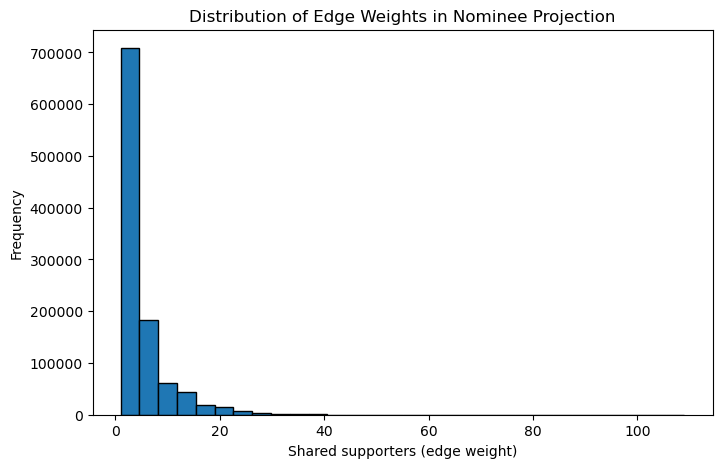

In [55]:
plt.figure(figsize=(8,5))
plt.hist(proj_weights, bins=30, edgecolor="black")
plt.title("Distribution of Edge Weights in Nominee Projection")
plt.xlabel("Shared supporters (edge weight)")
plt.ylabel("Frequency")
plt.show()

## Edge Weight Distribution

We analyzed the distribution of edge weights in the projected network, where each weight represents the number of shared supporters between two nominees.

The distribution is highly right-skewed:
- Most nominee pairs share only a small number of voters
- A small number of pairs share a large number of voters (up to 109)

This suggests that while many nominees have minimal overlap in support, a few pairs are strongly connected, likely indicating similar voter bases or closely related candidacies.

This may represent tightly connected groups or clusters within the network.

In [57]:
proj_components = sorted(nx.connected_components(nominee_projection), key=len, reverse=True)
largest_proj_nodes = proj_components[0]
largest_proj_cc = nominee_projection.subgraph(largest_proj_nodes).copy()

print("Largest projected component nodes:", largest_proj_cc.number_of_nodes())
print("Largest projected component edges:", largest_proj_cc.number_of_edges())

Largest projected component nodes: 1993
Largest projected component edges: 1044352


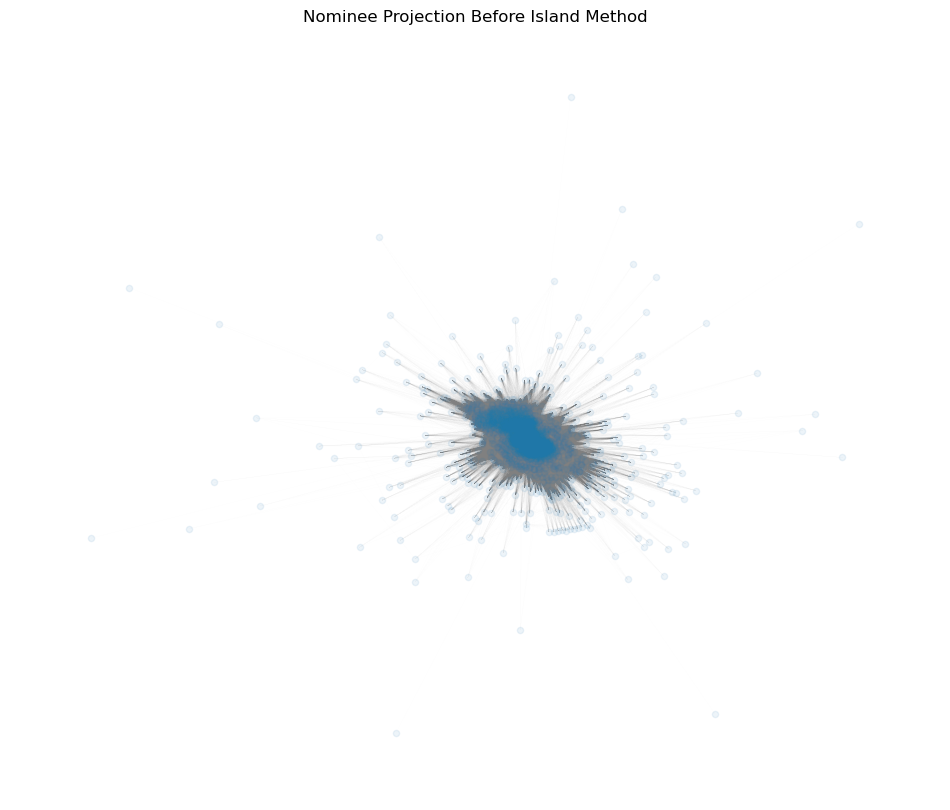

In [59]:
plt.figure(figsize=(12, 10))

pos_before = nx.spring_layout(largest_proj_cc, seed=42, k=0.15)

nx.draw_networkx(
    largest_proj_cc,
    pos=pos_before,
    with_labels=False,
    node_size=20,
    node_color="#1f77b4",
    width=0.05,
    edge_color="gray",
    alpha=0.08
)

plt.title("Nominee Projection")
plt.axis("off")
plt.show()

## Visualization

- We wanted to visualize the projected nominee network before applying the island method.
- As we can see above is extremely dense, resulting in a highly cluttered visualization where most nodes are connected through overlapping edges.
- The structure is quite dense, making it difficult to identify meaningful patterns, clusters, or important nodes because of the large number of weak connections created by shared voters across many nominees.

This visualization highlights more than ever the need for network reduction techniques like the island method, to remove low-weight edges and reveal more interpretable structure.

In [22]:
def trim_edges_by_weight(g, min_weight=2):
    """
    Return a new graph containing only edges with weight >= min_weight.
    Keeps node attributes when possible.
    """
    g2 = nx.Graph()
    
    # add nodes first
    for n, data in g.nodes(data=True):
        g2.add_node(n, **data)
    
    # add only strong edges
    for u, v, data in g.edges(data=True):
        if data.get("weight", 1) >= min_weight:
            g2.add_edge(u, v, **data)
    
    # remove isolates after trimming
    isolates = list(nx.isolates(g2))
    g2.remove_nodes_from(isolates)
    
    return g2

In [36]:
for w in [5, 10, 15, 20, 30, 40, 50]:
    G_test = trim_edges_by_weight(nominee_projection, min_weight=w)
    n_nodes = G_test.number_of_nodes()
    n_edges = G_test.number_of_edges()
    n_components = nx.number_connected_components(G_test) if n_nodes > 0 else 0
    
    if n_nodes > 0:
        largest_cc_size = max(len(c) for c in nx.connected_components(G_test))
    else:
        largest_cc_size = 0
    
    print(
        f"min_weight={w:>2} | nodes={n_nodes:>4} | edges={n_edges:>6} | "
        f"components={n_components:>4} | largest_cc={largest_cc_size:>4}"
    )

min_weight= 5 | nodes=1620 | edges=335902 | components=   1 | largest_cc=1620
min_weight=10 | nodes=1438 | edges=128226 | components=   1 | largest_cc=1438
min_weight=15 | nodes=1274 | edges= 55700 | components=   1 | largest_cc=1274
min_weight=20 | nodes=1078 | edges= 24847 | components=   1 | largest_cc=1078
min_weight=30 | nodes= 614 | edges=  5174 | components=   2 | largest_cc= 612
min_weight=40 | nodes= 305 | edges=  1213 | components=   2 | largest_cc= 303
min_weight=50 | nodes= 134 | edges=   354 | components=   2 | largest_cc= 127


## Island Method
To reduce the density of the projected network and focus on stronger relationships, we applied the **island method**.

As the minimum edge weight increases, the network becomes significantly smaller and less dense.

At lower thresholds ( 5–20), the network remained highly connected with a single large component, which shows us that there is widespread overlap in voter support across nominees.

However, as the threshold increases (30–50):
- The number of nodes and edges drops sharply
- The network begins to split into multiple connected components
- Only the strongest relationships remain

This demonstrates that while many nominees share some voters, only a smaller subset share a large number of common supporters, forming more meaningful clusters.

In [37]:
G_island = trim_edges_by_weight(nominee_projection, min_weight=50)

print("Reduced nominee graph nodes:", G_island.number_of_nodes())
print("Reduced nominee graph edges:", G_island.number_of_edges())

Reduced nominee graph nodes: 134
Reduced nominee graph edges: 354


We decided to use a threshold of 50, and we were able to obtain a much smaller network with:
- 134 nodes
- 354 edges

This filtered network represents only the strongest connections between nominees, and each edge reflected at least 50 shared supporters.

In [38]:
reduced_degrees = dict(G_island.degree())

reduced_degree_df = pd.DataFrame({
    "node": list(reduced_degrees.keys()),
    "degree": list(reduced_degrees.values())
}).sort_values("degree", ascending=False)

reduced_degree_df.head(10)

,node,degree
23,nominee_2625,46
73,nominee_2328,41
62,nominee_3352,35
108,nominee_3456,31
128,nominee_737,27
53,nominee_2398,18
37,nominee_3089,17
89,nominee_4037,16
9,nominee_1297,15
59,nominee_3537,14


In [39]:
print("Connected components:", nx.number_connected_components(G_island))

component_sizes = sorted([len(c) for c in nx.connected_components(G_island)], reverse=True)
print("Top 10 component sizes:", component_sizes[:10])

Connected components: 2
Top 10 component sizes: [127, 7]


In [40]:
largest_cc_nodes = max(nx.connected_components(G_island), key=len)
largest_cc = G_island.subgraph(largest_cc_nodes).copy()

print("Largest component nodes:", largest_cc.number_of_nodes())
print("Largest component edges:", largest_cc.number_of_edges())

Largest component nodes: 127
Largest component edges: 348


## Connected Components Analysis

After applying the island method, the network was split into 2 connected components.

The largest component contains 127 nodes, while the second component is much smaller (7 nodes), suggesting a dominant cluster with closely related nominees.

This suggests that a large group of nominees shares strong overlap in voter support, while a smaller group forms a separate cluster with limited connections to the main network.

In [56]:
print("Bipartite Graph Summary")
print(f"Voter nodes: {num_voters}")
print(f"Nominee nodes: {num_nominees}")
print(f"Total nodes: {num_nodes}")
print(f"Total edges: {num_edges}")

print("\nReduced Projected Graph Summary")
print(f"Nodes after island method: {G_island.number_of_nodes()}")
print(f"Edges after island method: {G_island.number_of_edges()}")
print(f"Connected components after reduction: {nx.number_connected_components(G_island)}")
print(f"Largest component size: {largest_cc.number_of_nodes()}")

Bipartite Graph Summary
Voter nodes: 5504
Nominee nodes: 2043
Total nodes: 7547
Total edges: 81862

Reduced Projected Graph Summary
Nodes after island method: 134
Edges after island method: 354
Connected components after reduction: 2
Largest component size: 127


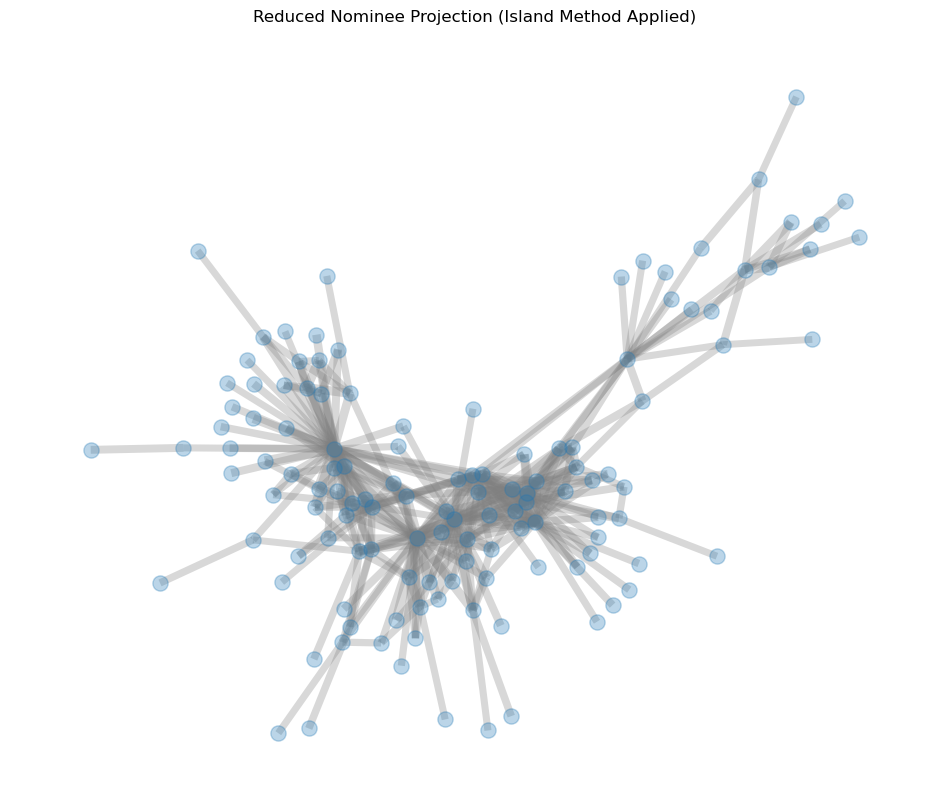

In [43]:
plt.figure(figsize=(12, 10))

pos = nx.spring_layout(largest_cc, seed=42, k=0.5)

edge_widths = [d["weight"] / 10 for _, _, d in largest_cc.edges(data=True)]

nx.draw_networkx(
    largest_cc,
    pos=pos,
    with_labels=False,
    node_size=120,
    node_color="#1f77b4",
    width=edge_widths,
    edge_color="gray",
    alpha=0.3
)

plt.title("Reduced Nominee Projection (Island Method Applied)")
plt.axis("off")
plt.show()

The visualization of the largest connected component shows a clear clustered structure.

Nodes are more tightly grouped, and the remaining edges represent strong relationships between nominees. Compared to the original dense network, this reduced graph is significantly more interpretable and highlights key hubs and clusters.

This confirms that the island method is effective in simplifying complex networks and uncovering meaningful patterns of shared support.